Real-Time Credit Risk Simulation

Lightweight, real-time credit risk analysis pipeline that simulates event ingestion, processes streaming data in pandas, applies logistic regression for prediction, and generates actionable business recommendations.

Sets up the environment and imports `run_pipeline()`.

Checks if the output parquet file exists and deletes it to ensure a fresh pipeline run.

Prints a message to indicate whether the file was removed or not.


In [1]:
import sys
import pandas as pd
import threading
import time
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------

from pathlib import Path
from src.pipeline import run_pipeline
from src.viz.plots import Plots

# -----------------------------
# Display full dataframes
# -----------------------------

pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to processed parquet file
# -----------------------------
file_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet'
)

# -----------------------------
# Delete existing parquet file for a fresh execution
# -----------------------------
if file_path.exists():
    file_path.unlink()
    print(f"Deleted existing file: {file_path}", flush=True)
else:
    print("No existing parquet file found. Continuing...", flush=True)

Deleted existing file: /Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet


Runs `run_pipeline()` in a separate thread so the notebook can monitor progress in real time.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

In [2]:
# -----------------------------
# Initialize variables
# -----------------------------
previous_shape = (0, 0)
current_df = pd.DataFrame(columns=[])

# -----------------------------
# Start pipeline in a separate thread
# -----------------------------
pipeline_thread = threading.Thread(target=run_pipeline, daemon=True)
pipeline_thread.start()
print("Monitoring parquet file for updates...\n")

# -----------------------------
# Real-time monitoring loop
# -----------------------------
while pipeline_thread.is_alive():
    if file_path.exists():
        try:
            df = pd.read_parquet(file_path, engine='fastparquet')
            if not df.empty and df.shape != previous_shape:
                previous_shape = df.shape
        except Exception:
            pass
    time.sleep(0.05)

# -----------------------------
# Wait for pipeline thread to finish
# -----------------------------
pipeline_thread.join()

Monitoring parquet file for updates...

Event producing has initiated.
Event consuming has initiated.

Processing is complete.



The pandas describe() method is executed on the final DataFrame to return summary statistics of its numerical columns.

In [3]:
# -----------------------------
# Data Statistics of final DataFrame
# -----------------------------
df.describe()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years,is_missing_revenue,is_missing_rated_exposure
count,40000.000000,32323.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,51.315075,6497.097578,355.769541,0.786081,0.708475,0.469550,0.533100,0.208025,0.191925,0.025125
std,14.657874,13296.011541,2580.942833,1.114318,5.929723,5.896986,5.917996,0.405900,0.393819,0.156507
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,3300.000000,0.176200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,5188.000000,0.372708,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,62.000000,8000.000000,0.855693,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,107.000000,1794060.000000,326442.000000,10.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000


After the pipeline finishes, the parquet file containing cleaned data is closed. The file is read which creates the final dataframe. Customized EDA including the final Dataframe's size, columns, and various column visualizations are displayed below. 

NOTE: These graphs were created prior to my discovery of the plotting approaches suggested in within the project instructions. They are included here to demonstrate my ability to create custom visualizations using matplotlib and seaborn.

Final dataFrame shape: (45063, 10)

Final dataFrame columns: Index(['age', 'monthly_revenue', 'debt_ratio', 'rated_exposure',
       'overdue_30_59_days', 'overdue_60_89_days', 'overdue_90_plus_days',
       'serious_delinquencies_past_2_years', 'is_missing_revenue',
       'is_missing_rated_exposure'],
      dtype='object')



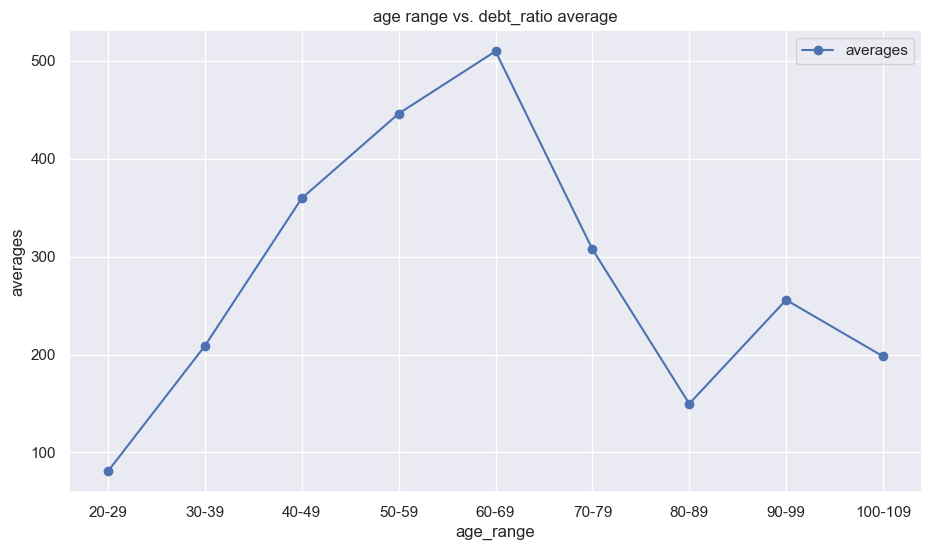

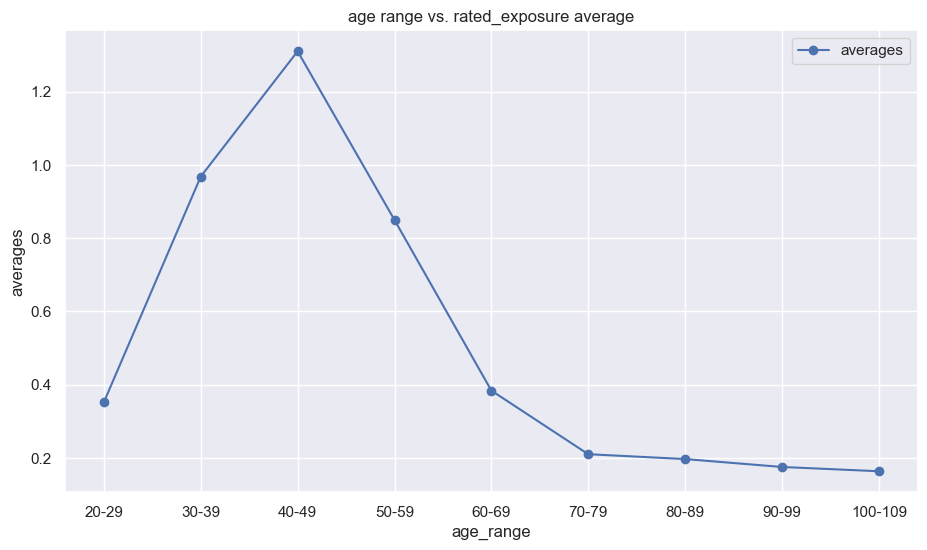

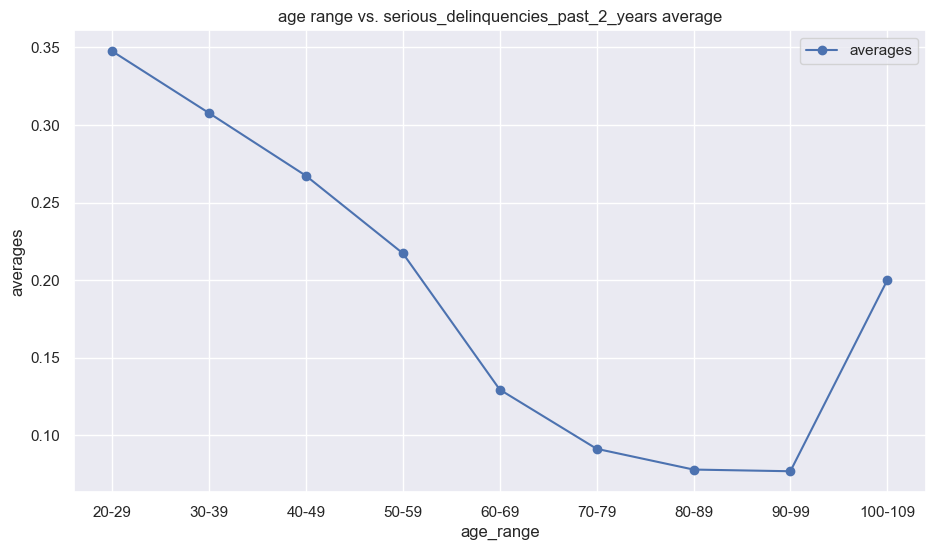

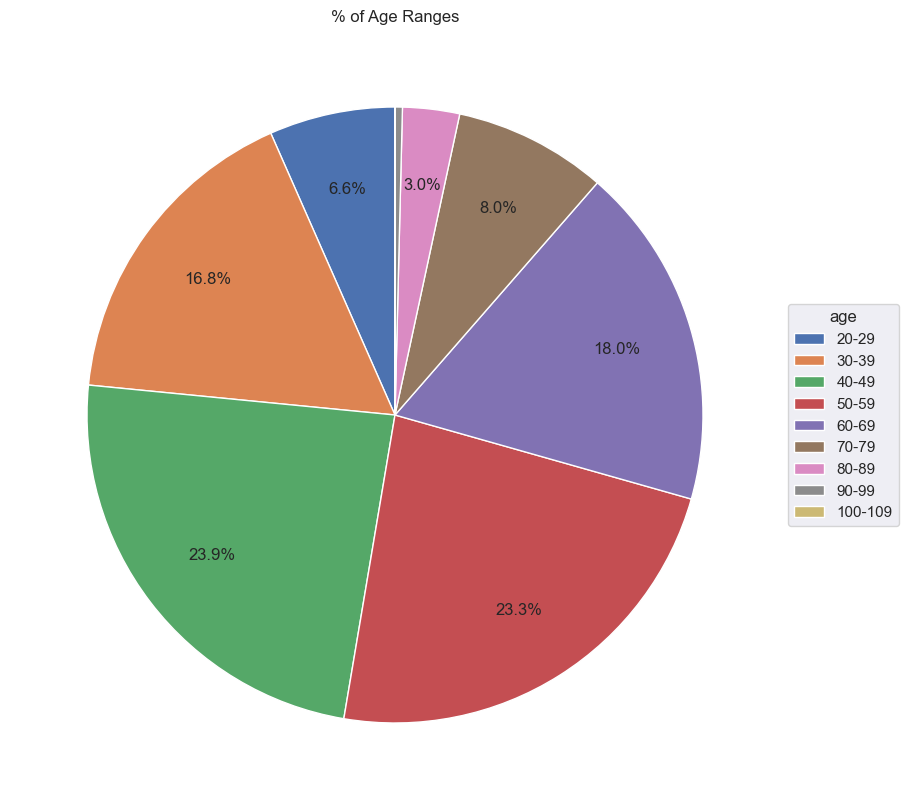

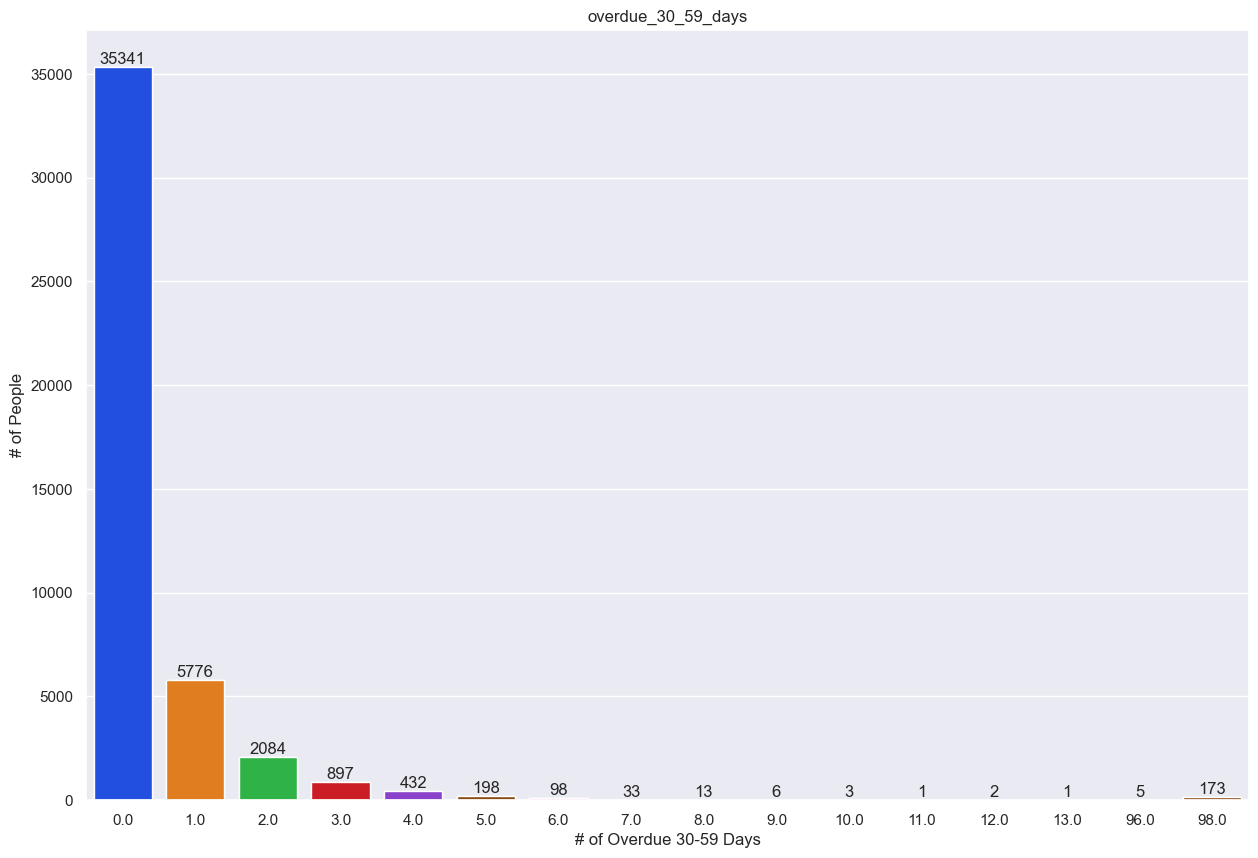

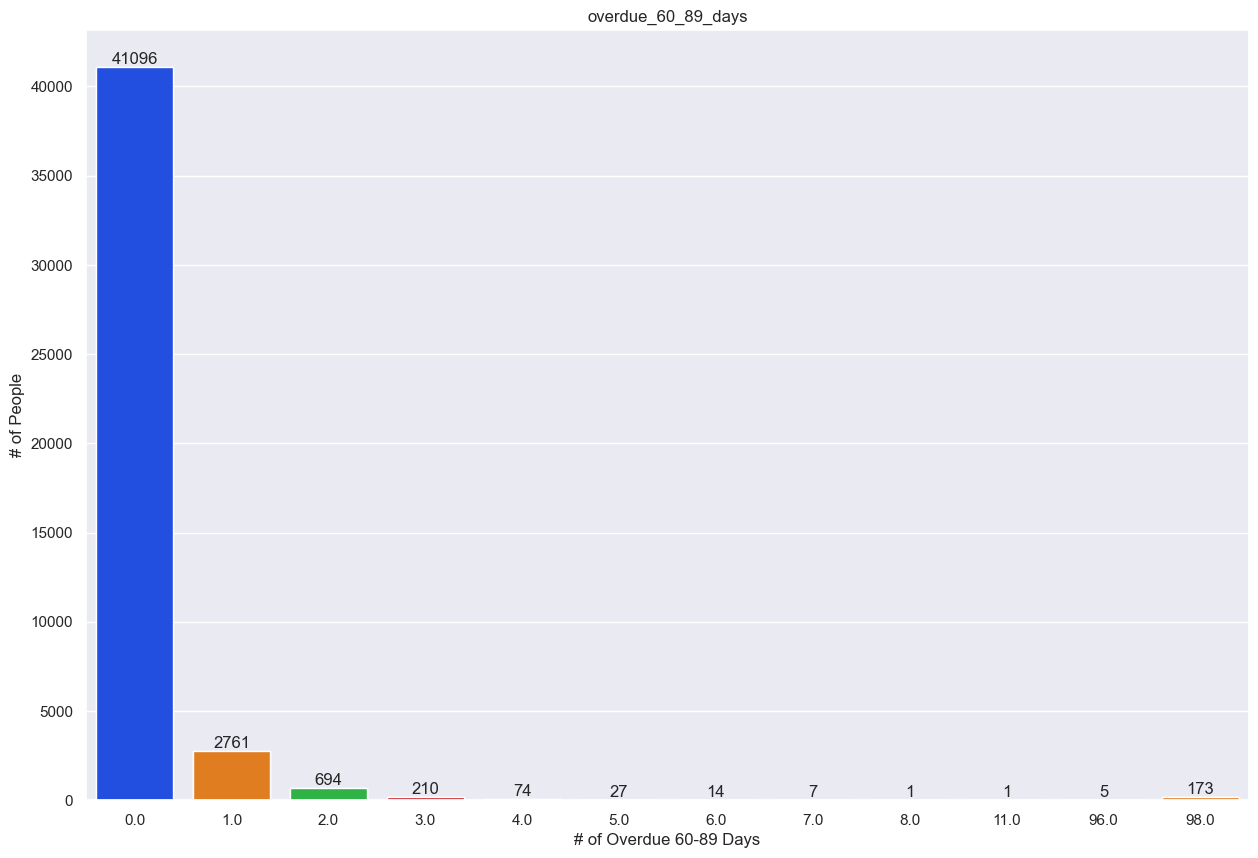

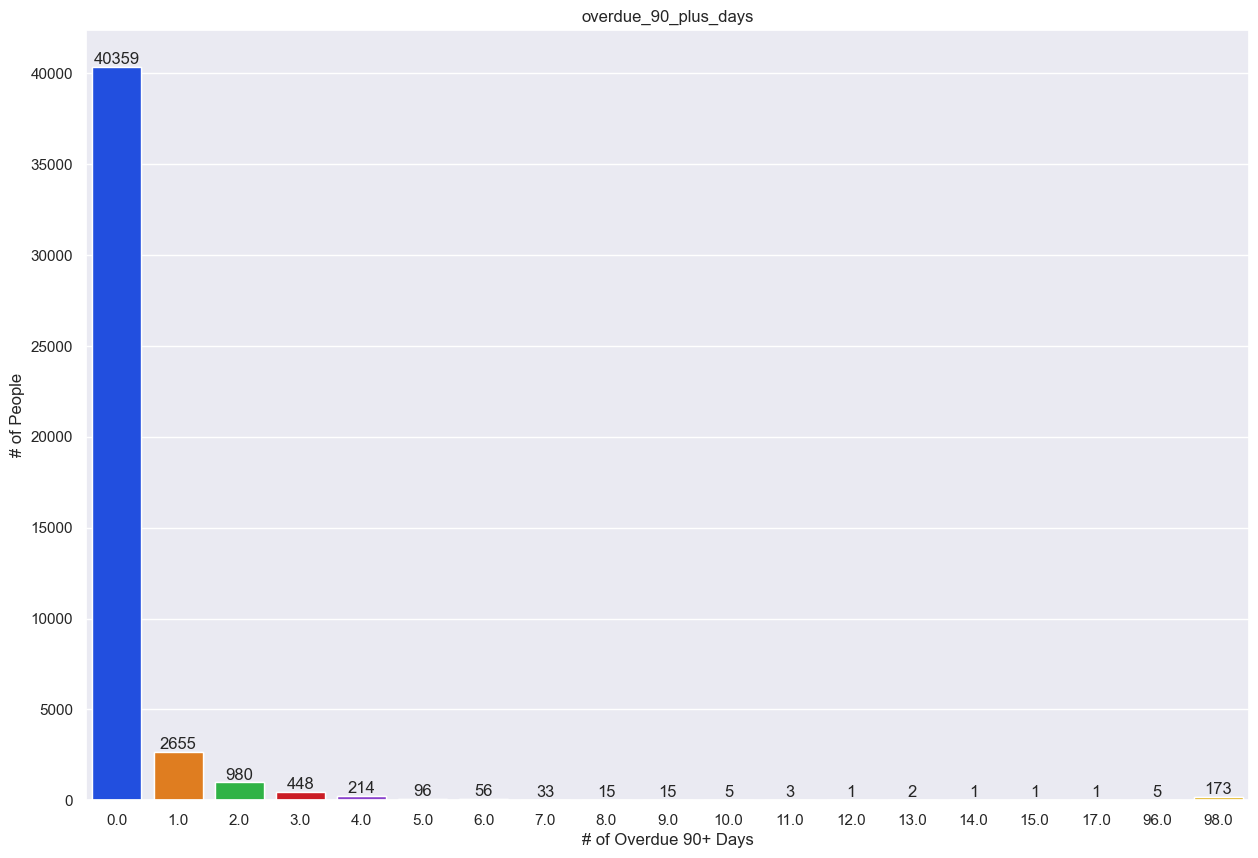

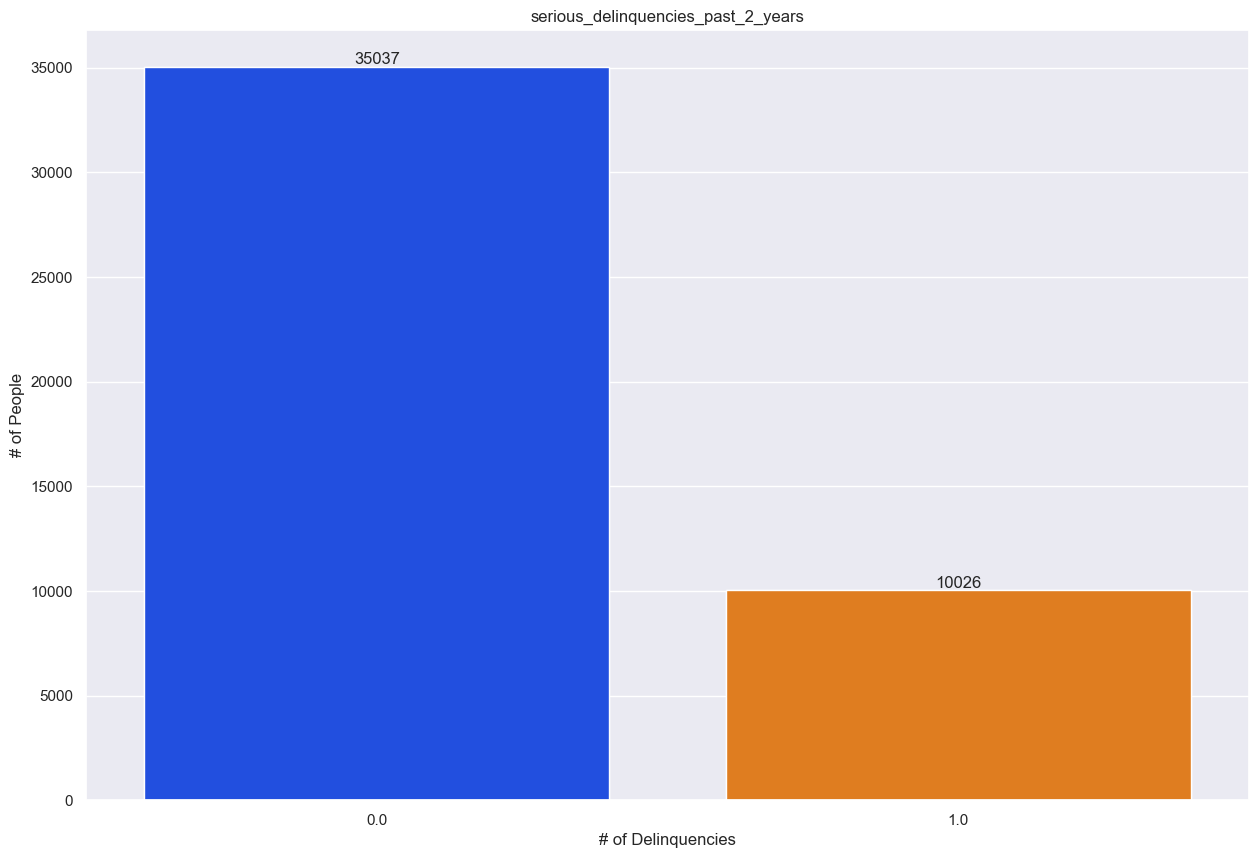

In [4]:
# -----------------------------
# Custom graphs of the final DataFrame
# -----------------------------
if file_path.exists():
    sns.set_theme()
    df_custom = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Final dataFrame shape: {df_custom.shape}\n")
    print(f"Final dataFrame columns: {df_custom.columns}\n")

    """Line Graphs (Custom)"""
    Plots.plot_age_range_comparison_avg(df_custom, 'age', 'debt_ratio')
    Plots.plot_age_range_comparison_avg(df_custom, 'age', 'rated_exposure')
    Plots.plot_age_range_comparison_avg(df_custom, 'age', 'serious_delinquencies_past_2_years')

    """Pie Graphs (Custom)"""
    Plots.plot_age_ranges(df_custom, df_custom.columns[0], title='% of Age Ranges')

    """Bar Graphs (Custom)"""
    Plots.plot_days_overdue_counts(df_custom, 'overdue_30_59_days', x_label='# of Overdue 30-59 Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df_custom, 'overdue_60_89_days', x_label='# of Overdue 60-89 Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df_custom, 'overdue_90_plus_days', x_label='# of Overdue 90+ Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df_custom, 'serious_delinquencies_past_2_years', x_label='# of Delinquencies', y_label='# of People')

    plt.show()

else:
    print("Pipeline finished but file was not found.")

The assignment's recommended EDA including the initial line plot, outlier removal, and the first bar plot of age vs. overdue_30_59_days are shown below.

Initial DataFrame shape: (45063, 10)

Final DataFrame shape: (36319, 10)



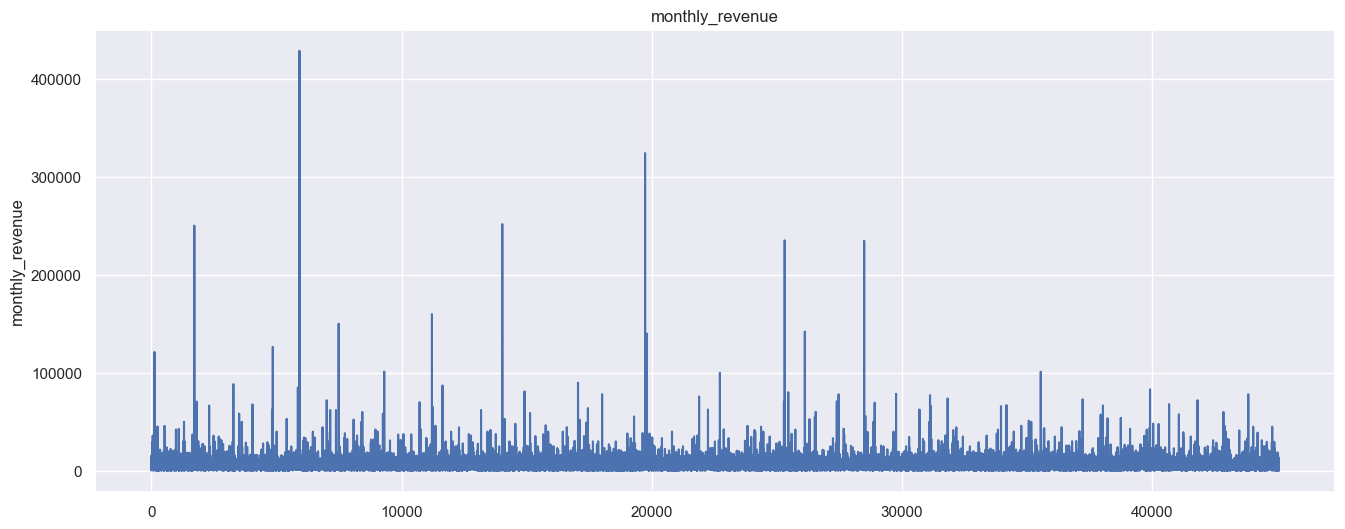

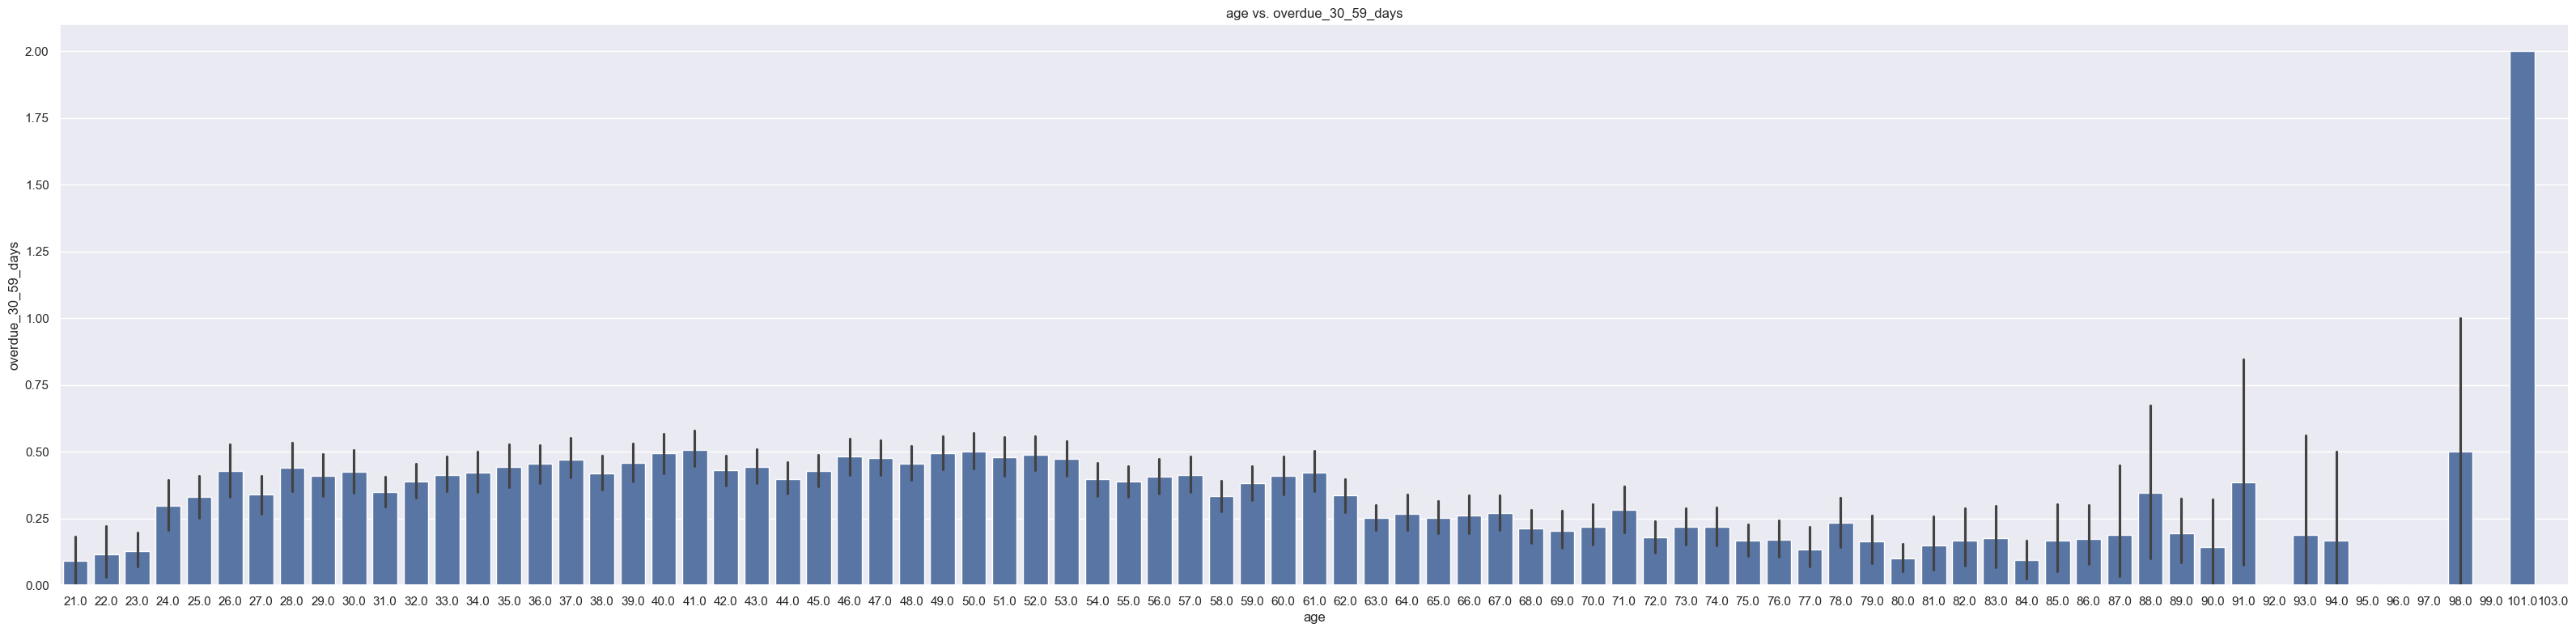

In [5]:
# -----------------------------
# Recommended EDA of the final DataFrame
# -----------------------------
if file_path.exists():
    sns.set_theme()
    df = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Initial DataFrame shape: {df.shape}\n")

    """Seaborn and Line Plots"""
    # plt.figure(figsize=(16,6))
    # sns.lineplot(data=df['monthly_revenue'])

    """Removing Outliers"""
    df = df[(df['overdue_90_plus_days'] < 32)] # removes rows where # of overdue payments >= 32 for 90+ days
    df = df[(df['overdue_60_89_days'] < 32)] # removes rows where # of overdue payments >= 32 for 60-89 days
    df = df[(df['overdue_30_59_days'] < 32)] # removes rows where # of overdue payments >= 32 for 30-59 days
    df = df[(df['monthly_revenue'] < 500000)] # removes rows where monthly revenue >= $500,000

    print(f"Final DataFrame shape: {df.shape}\n")
    plt.figure(figsize=(16,6))
    plt.title('monthly_revenue')
    sns.lineplot(data=df['monthly_revenue'])

    """More Types of Visualizations"""
    plt.figure(figsize=(40,9))
    plt.title('age vs. overdue_30_59_days')
    plt.xlabel('age')
    
    sns.barplot(x=df['age'], y=df['overdue_30_59_days'])

    plt.show()

else:
    print("Pipeline finished but file was not found.")

Bar graph for age vs. overdue_60_89_days

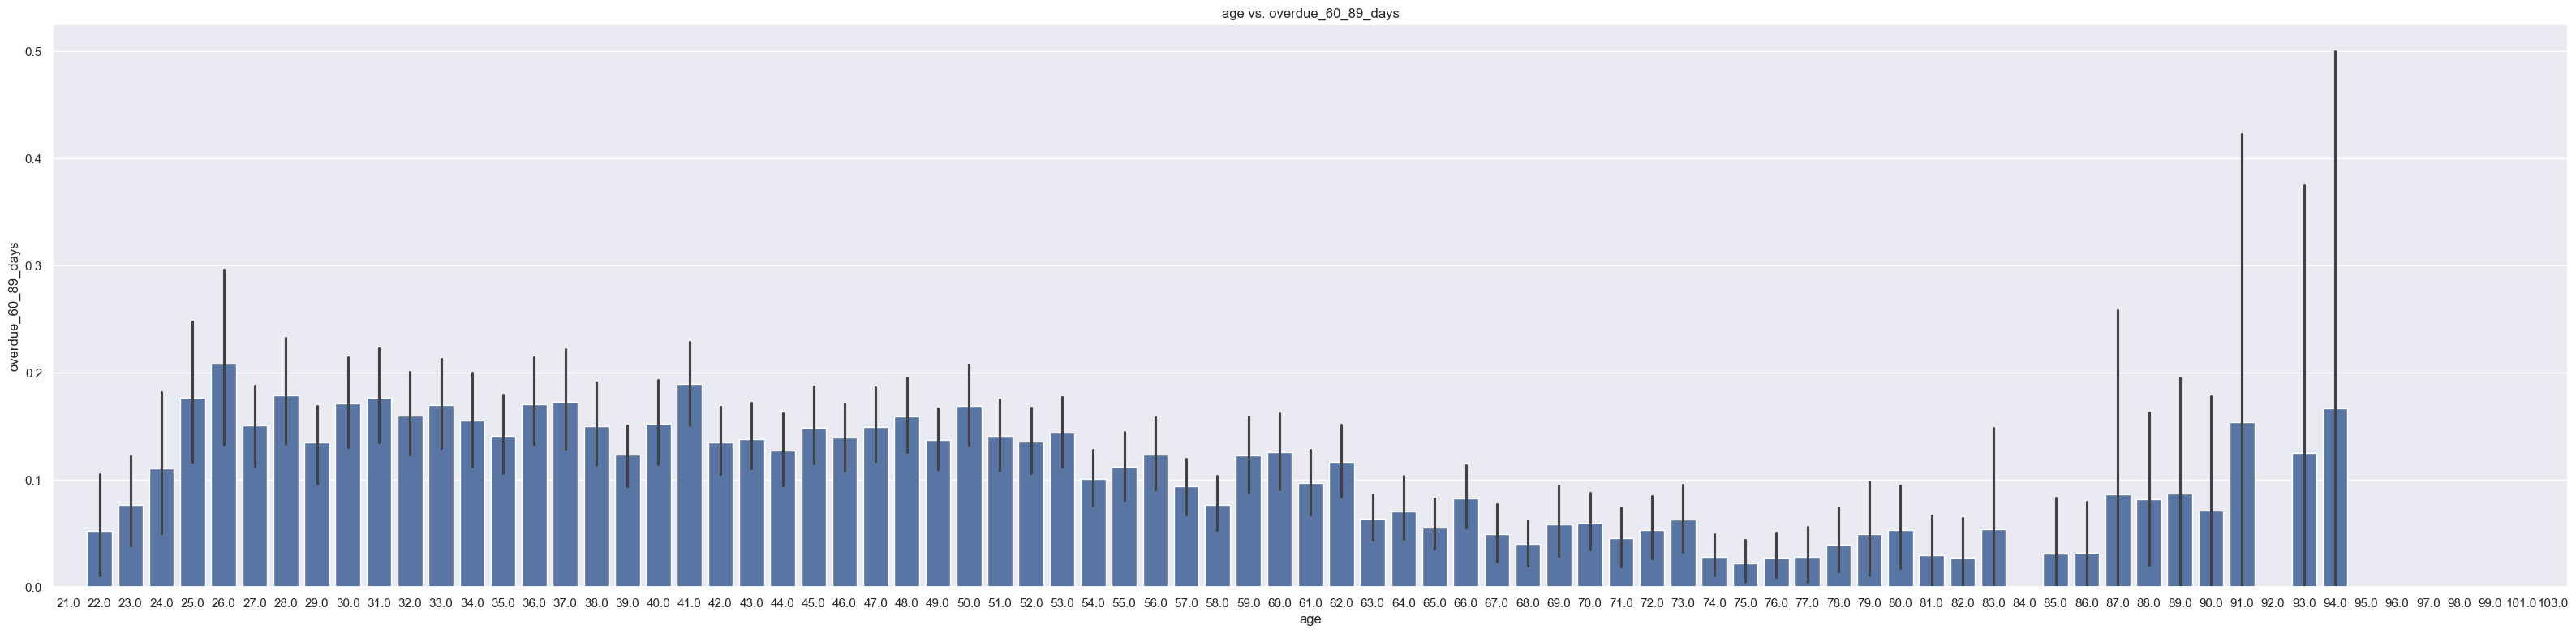

In [6]:
# -----------------------------
# Recommended EDA of the final DataFrame
# -----------------------------

"""More Types of Visualizations (cont.)"""
plt.figure(figsize=(40,9))
plt.title('age vs. overdue_60_89_days')
plt.xlabel('age')

sns.barplot(x=df['age'], y=df['overdue_60_89_days'])

plt.show()

Bar graph for age vs. overdue_90_plus_days

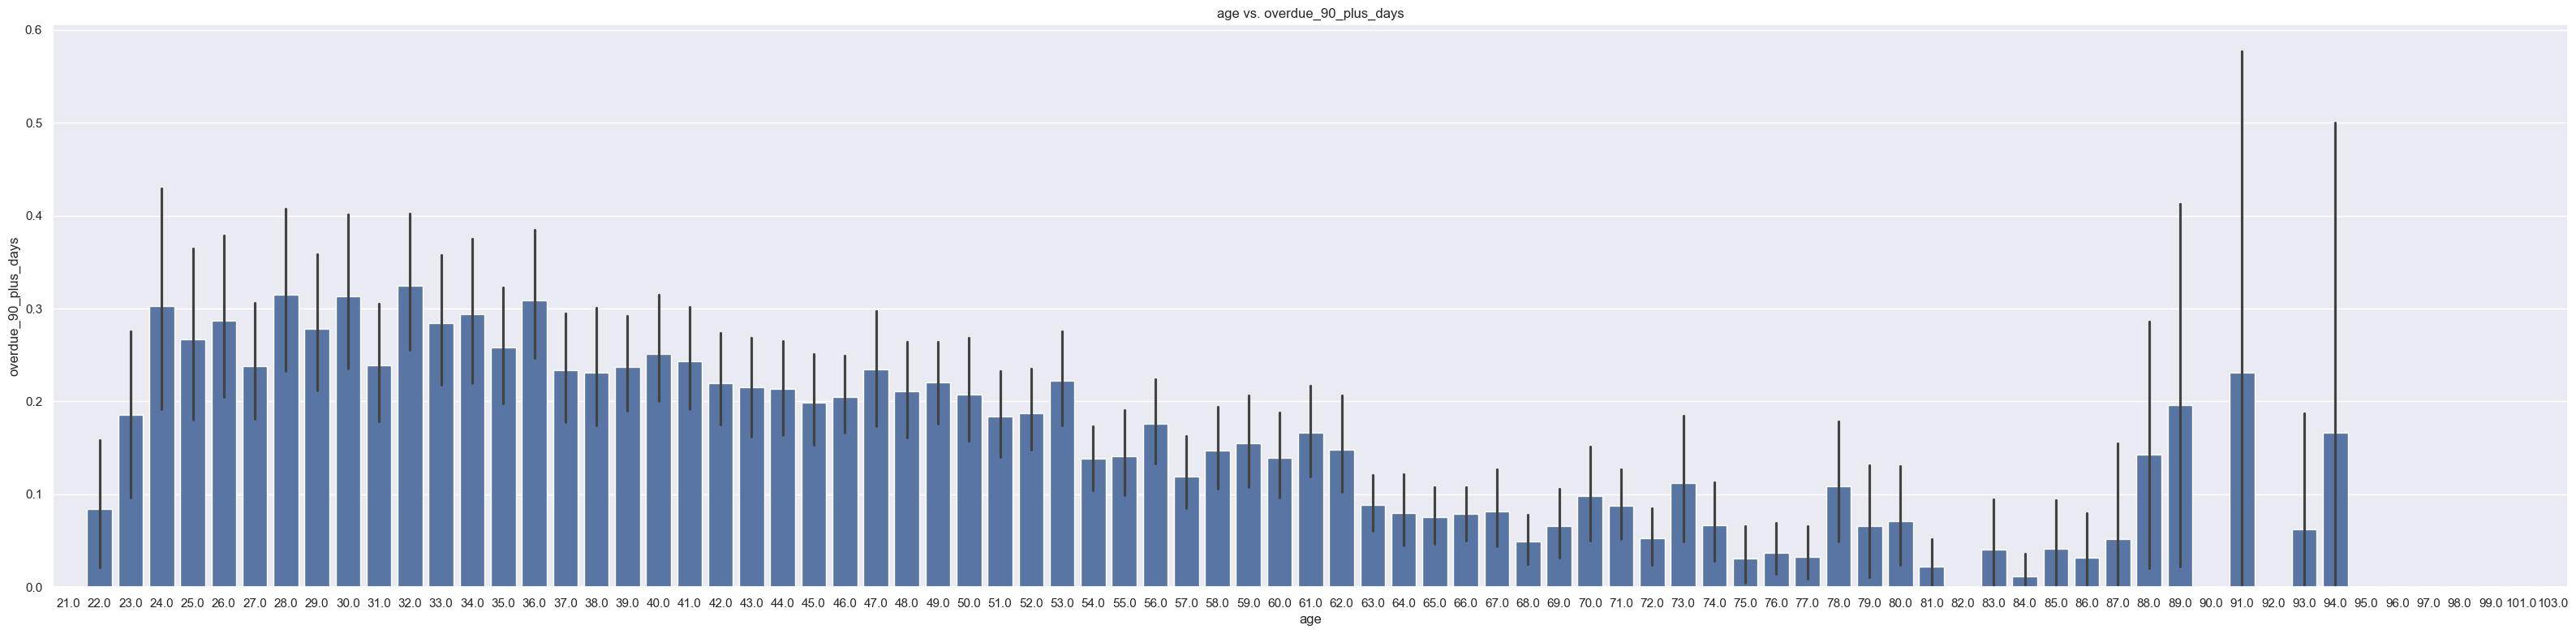

In [7]:
# -----------------------------
# Recommended EDA of the final DataFrame
# -----------------------------

"""More Types of Visualizations (cont.)"""
plt.figure(figsize=(40,9))
plt.title('age vs. overdue_90_plus_days')
plt.xlabel('age')

sns.barplot(x=df['age'], y=df['overdue_90_plus_days'])

plt.show()

Bar graph for age vs. serious_delinquencies_past_2_years

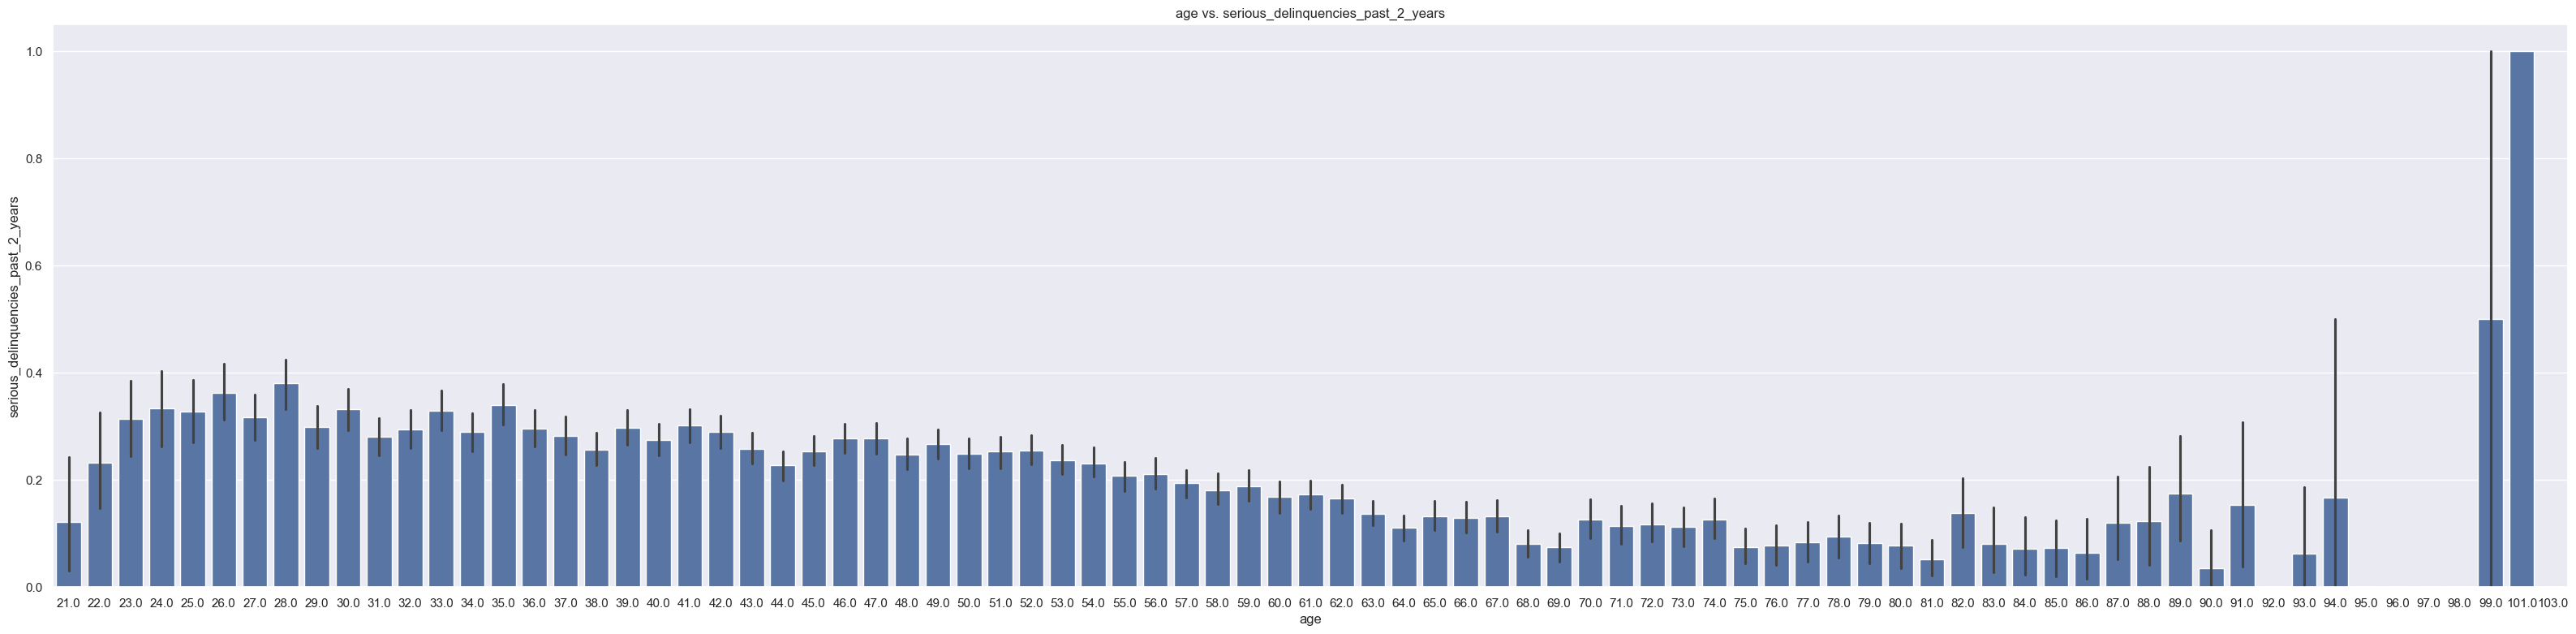

In [8]:
# -----------------------------
# Recommended EDA of the final DataFrame
# -----------------------------

"""More Types of Visualizations (cont.)"""
plt.figure(figsize=(40,9))
plt.title('age vs. serious_delinquencies_past_2_years')
plt.xlabel('age')

sns.barplot(x=df['age'], y=df['serious_delinquencies_past_2_years'])

plt.show()